# Lab: Machine Learning

**Name:** Shaikh Muhammad<br>
**CMS:**  023-24-0175 <br>
**Github:** https://github.com/mrshaikhmuhammad/machine-learning 


1. Load clean_churn.csv (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no
missing values remaining.

In [52]:
import pandas as pd

df = pd.read_csv("clean_churn.csv")

print("~"*50)
print("SHAPE VALIDATION")
print("~"*50)
print("(row, columns) = ",df.shape)
print("~"*50, end="\n\n")

print("~"*50)
print("INFO VALIDATION")
print("~"*50)
print(df.info())
print("~"*50, end="\n\n")

print("~"*50)
print("VALUE COUNTS")
print("~"*50)
print(df["Churn"].value_counts())
print("~"*50, end="\n\n")


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
SHAPE VALIDATION
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
(row, columns) =  (7043, 20)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
INFO VALIDATION
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  Device

2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the
business?

In [53]:
# We are trying to calculation amount churn (rate at which customers stop using our services). It is important for business to understand the churn rate as it directly impacts revenue and growth. By analyzing the churn data, we can identify patterns allowing us to reduce chrun and improve customer relations.

3. Define y as the Churn column, encoded as 0/1. Define X as the remaining relevant columns — drop any
identifier column still present.

In [54]:
df.dropna(inplace=True)
y=df["Churn"].map({"Yes": 1, "No": 0})
x=df.drop(columns=["Churn"])

print(y)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64


4. Convert every remaining categorical column in X into numeric form. Briefly justify your choice of encoding
method (e.g. one-hot vs. manual mapping).

In [55]:
binary_cols = ["SeniorCitizen", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
multi_val_cols = ["gender", "MultipleLines", "InternetService", "Contract", "PaymentMethod", "OnlineSecurity","OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

x[binary_cols] = x[binary_cols].replace({"Yes": 1, "No": 0})

x = pd.get_dummies(x, columns=multi_val_cols, drop_first=True, dtype=int)

/tmp/ipykernel_9707/2393835113.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x[binary_cols] = x[binary_cols].replace({"Yes": 1, "No": 0})


5. Confirm X contains only numeric columns and has no missing values before moving on.

In [56]:
print(x.value_counts)

<bound method DataFrame.value_counts of       SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0                 0        1           0       1             0   
1                 0        0           0      34             1   
2                 0        0           0       2             1   
3                 0        0           0      45             0   
4                 0        0           0       2             1   
...             ...      ...         ...     ...           ...   
7038              0        1           1      24             1   
7039              0        1           1      72             1   
7040              0        1           1      11             0   
7041              1        1           0       4             1   
7042              0        0           0      66             1   

      PaperlessBilling  MonthlyCharges  TotalCharges  gender_Male  \
0                    1           29.85         29.85            0   
1                    0       

6. Split X and y into training and test sets (e.g. an 80/20 split). Why is stratify=y a sensible choice, given what you found about the target's class balance in Lab 2?

In [57]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

7. Report the shape of X_train, X_test, y_train, and y_test.

In [58]:
print("~"*50)
print("TRAIN TEST SPLIT VALIDATION")
print("~"*50)
print("x_train shape: ", x_train.shape)
print("x_test shape:  ", x_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape:  ", y_test.shape)
print("~"*50)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
TRAIN TEST SPLIT VALIDATION
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
x_train shape:  (5634, 30)
x_test shape:   (1409, 30)
y_train shape:  (5634,)
y_test shape:   (1409,)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


8. Train a DecisionTreeClassifier on the training data with default settings (only random_state fixed). Generate predictions on both the training and test sets.

In [59]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(
    max_depth=400,
    min_samples_split=10, 
    random_state=42
)

x_train.dropna(inplace=True)
y_train.dropna(inplace=True)
dtc.fit(x_train, y_train)

y_predicted =dtc.predict(x_test)



9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

In [60]:
print("Depth of the tree: ", dtc.get_depth())

Depth of the tree:  25


10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.

In [61]:
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score
print("Accuracy: ", accuracy_score(y_test, y_predicted))
print("Precision:", precision_score(y_test, y_predicted))
print("Recall:   ", recall_score(y_test, y_predicted))
print("F1 Score: ", f1_score(y_test, y_predicted))


Accuracy:  0.7331440738112136
Precision: 0.49538461538461537
Recall:    0.4316353887399464
F1 Score:  0.46131805157593125


11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how
many did it miss?

ConfusionMatrixDisplay: 


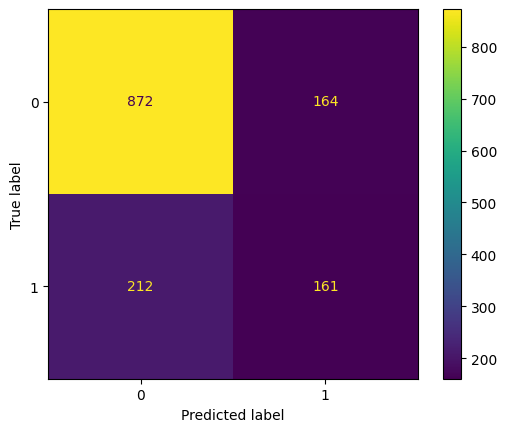

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay

print("ConfusionMatrixDisplay: \n", ConfusionMatrixDisplay.from_estimator(dtc, x_test, y_test))

12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

In [63]:
# I believe that the confusion metrix is a better metric to evaluate the models performace because it provide more detailed information about accuracy, precision and recall all at once.

13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model?

In [64]:
print("Accuracy Score on Traning Data: ", accuracy_score(y_train, dtc.predict(x_train)))
print("Accuracy Score on Test Data: ", accuracy_score(y_test, dtc.predict(x_test)))


Accuracy Score on Traning Data:  0.9132055378061767
Accuracy Score on Test Data:  0.7331440738112136


14. Train several Decision Trees at different max_depth values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table.

In [65]:
accuracy = []

for depth in range(1, 11):
    dt = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_split=10, 
        random_state=42
    )
    dt.fit(x_train, y_train)
    print(f"Depth: {depth}, Accuracy: ", accuracy_score(y_test, dt.predict(x_test)))
    accuracy.append(accuracy_score(y_test, dt.predict(x_test)))

Depth: 1, Accuracy:  0.7352732434350603
Depth: 2, Accuracy:  0.8019872249822569
Depth: 3, Accuracy:  0.8019872249822569
Depth: 4, Accuracy:  0.8026969481902059
Depth: 5, Accuracy:  0.8062455642299503
Depth: 6, Accuracy:  0.7977288857345636
Depth: 7, Accuracy:  0.7892122072391767
Depth: 8, Accuracy:  0.7814052519517388
Depth: 9, Accuracy:  0.7764371894960965
Depth: 10, Accuracy:  0.7643718949609652


15. Plot train accuracy and test accuracy against max_depth on the same chart. At roughly what depth does the
model start to overfit? Explain how the chart shows this

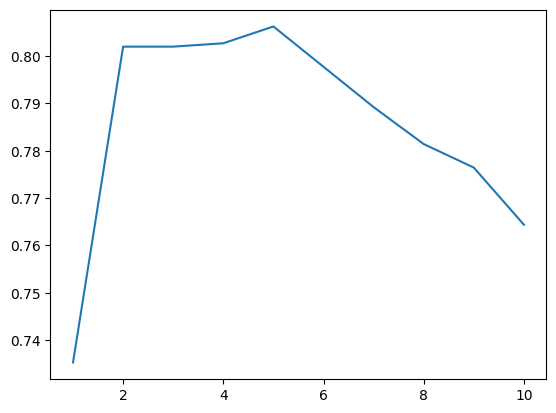

In [66]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), accuracy)

16. Based on your Part 6 table/plot, select a max_depth you consider the best model. Justify your choice in 2–3
sentences — it should not simply be the depth with the highest training accuracy.

In [67]:
#I believe by increasing the number of depth of the tree, we overfit the model which is good for the train data but its accuracy on test data decreases. This is because the model becomes too complex and starts to memorize the training data instead of learning the underlying patterns, leading to poor generalization on unseen data.

#Therefore model with the depth of 5 is the best model.

17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Part 5) for comparison against the baseline.

In [68]:
dtc = DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10, 
        random_state=42
    )
dtc.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


18. Retrain a Decision Tree with “entropy” as the splitting criterion rather than the default (“gini”) and report its full evaluation metrics (as in Part 5) for comparison against the baseline.

In [69]:
def evaluate(dtc, x_test, y_test, heading):
    print("~"*50)
    print(heading)
    print("~"*50)
    print("Accuracy: ", accuracy_score(y_test, dtc.predict(x_test)))
    print("Precision:", precision_score(y_test, dtc.predict(x_test)))
    print("Recall:   ", recall_score(y_test, dtc.predict(x_test)))
    print("F1 Score: ", f1_score(y_test, dtc.predict(x_test)))

evaluate(dtc, x_test, y_test, "Evaluation based on GINI Index")

dtc_entropy = DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        random_state=42,
        criterion="entropy"
)
dtc_entropy.fit(x_train, y_train)
evaluate(dtc_entropy, x_test, y_test, "Evaluation based on Entropy")



~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Evaluation based on GINI Index
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Accuracy:  0.8062455642299503
Precision: 0.7049180327868853
Recall:    0.46112600536193027
F1 Score:  0.5575364667747164
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Evaluation based on Entropy
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Accuracy:  0.7913413768630234
Precision: 0.6303630363036303
Recall:    0.5120643431635389
F1 Score:  0.5650887573964497


19. Extract and visualize feature_importances_ for your chosen model. Which 3–5 features matter most?

<BarContainer object of 30 artists>

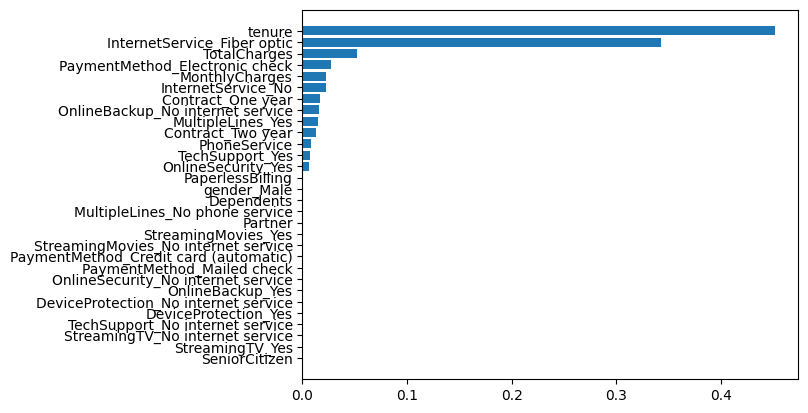

In [70]:
features = pd.Series(dtc.feature_importances_, index=x_train.columns).sort_values()

plt.barh(features.index, features.values)

20. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then?

In [71]:
# Yes i agree importance of tenure and internet service in the influencing the the churn rate. 

21. Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are its main limitations?

In [72]:
# i learned here decision tree classifier. it performs well when the dataset has clear relationship between its target and features. its limitation is, its easy to overfit the model.

22. What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling class imbalance)? Describe it — do not implement it here.

In [73]:
# i will try to explore random forest classifier and compare its performance with decision tree classifier.

23. Implement ID3 from scratch on the Play Badminton dataset from class. No built-in decision tree libraries —
write your own entropy and information gain functions. Print the gain values for each attribute at every
split.

In [86]:
import math
import kagglehub

path = kagglehub.dataset_download("aditya0kumar0tiwari/play-badminton")
df = pd.read_csv(path + "/badminton_dataset.csv")

def entropy(attribute, target, df, value=None):
    if value is not None:
        df = df[df[attribute] == value]

    counts = df[target].value_counts()
    p = counts.get("Yes", 0)
    n = counts.get("No",  0)
    total = p + n
    if total == 0:
        return 0
    
    result = 0
    for count in (p, n):
        if count > 0:  
            prob = count / total
            result -= prob * math.log2(prob)
    return result

def average_info(attribute, target, df):
    avg_info = 0
    total = len(df)

    for value in df[attribute].unique():
        subset = df[df[attribute] == value]
        weight = len(subset) / total
        avg_info += weight * entropy(attribute, target, df, value=value)

    return avg_info

def gain(attribute, target, df):
    return entropy(attribute, target, df) - average_info(attribute, target, df)

def make_tree(df, target):
    for attribute in df.columns:
        if attribute != target:
            print(f"Gain for {attribute}: {gain(attribute, target, df):.2f}")


make_tree(df, "Play_Badminton")            

Gain for Outlook: 0.25
Gain for Temperature: 0.00
Gain for Humidity: 0.00
Gain for Wind: 0.46
